In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "7"

import torch
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

1
NVIDIA A100-SXM4-80GB


/scratch/sahil/anaconda3/envs/dif/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda:1
Model: efficientnet-b4, Target: _blocks[-1]
Helpers ready.
  CelebDF real         ./test_images_celebdf/Celeb-real                   OK (580 images)
  CelebDF real         ./test_images_celebdf/YouTube-real                 OK (297 images)
  CelebDF fake         ./test_images_celebdf/Celeb-synthesis              OK (5621 images)
  DiffSwap fake        ./test_images_diffswap/DiffSwap                    OK (31265 images)
  FFpp real            ./test_images/original_sequences                   OK (1000 images)
  FFpp fake            ./test_images/manipulated_sequences                OK (4994 images)
  DFD real             ./test_images_dfd/DFD_original_sequences           OK (241 images)
  DFD fake             ./test_images_dfd/DFD_manipulated_sequences        OK (2578 images)
GradCAM ready.

=== Celeb-DF ===
  Celeb-DF: 580 real images, 5621 fake images found


    REAL picked: score=0.0400, path=frame_0.png
    REAL picked: score=0.0559, path=frame_0.png
    FAKE picked: score=0.4718, path=frame_0.png
    FAKE picked: score=0.3885, path=frame_0.png

=== DiffSwap ===
  DiffSwap: 1000 real images, 31265 fake images found


    REAL picked: score=0.0078, path=frame_0.png
    REAL picked: score=0.0128, path=frame_0.png
    FAKE picked: score=1.0000, path=frame_0.png
    FAKE picked: score=1.0000, path=frame_0.png

=== FF++ (backup) ===
  FF++: 1000 real images, 4994 fake images found


    REAL picked: score=0.0078, path=frame_0.png
    REAL picked: score=0.0107, path=frame_0.png
    FAKE picked: score=0.9999, path=frame_0.png
    FAKE picked: score=0.6629, path=frame_0.png


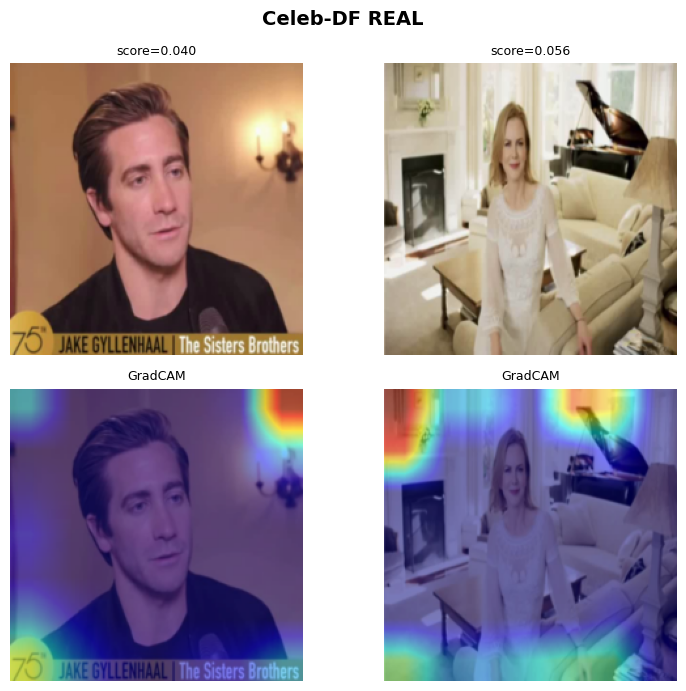

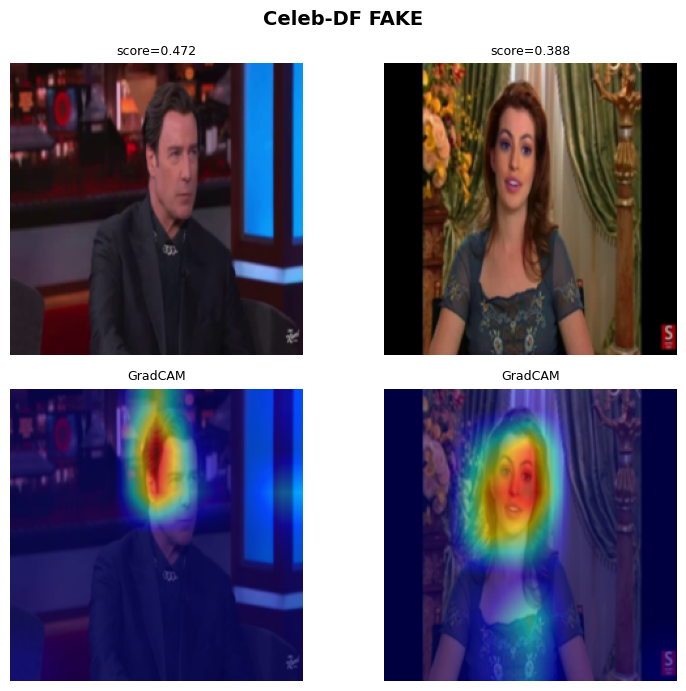

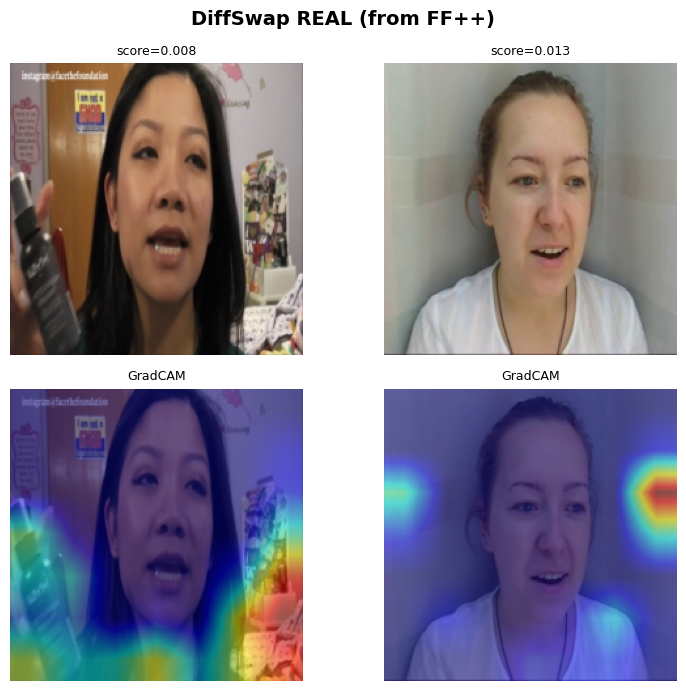

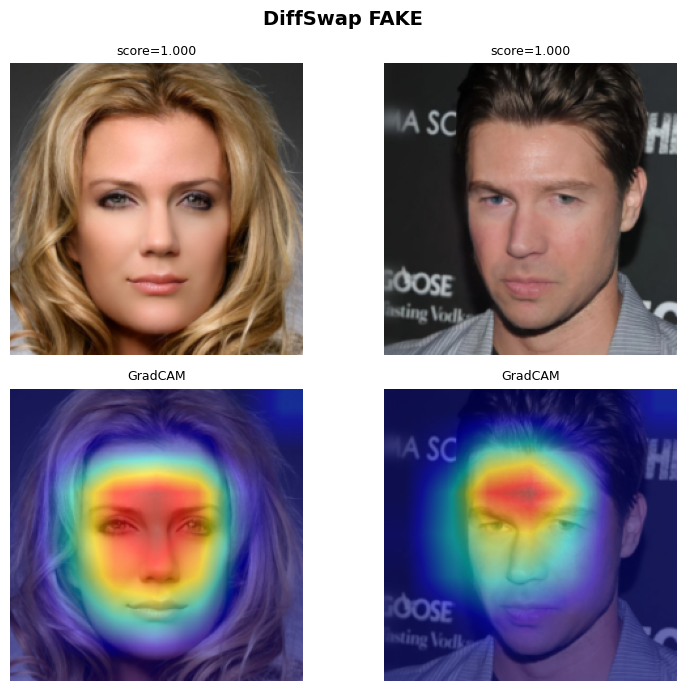

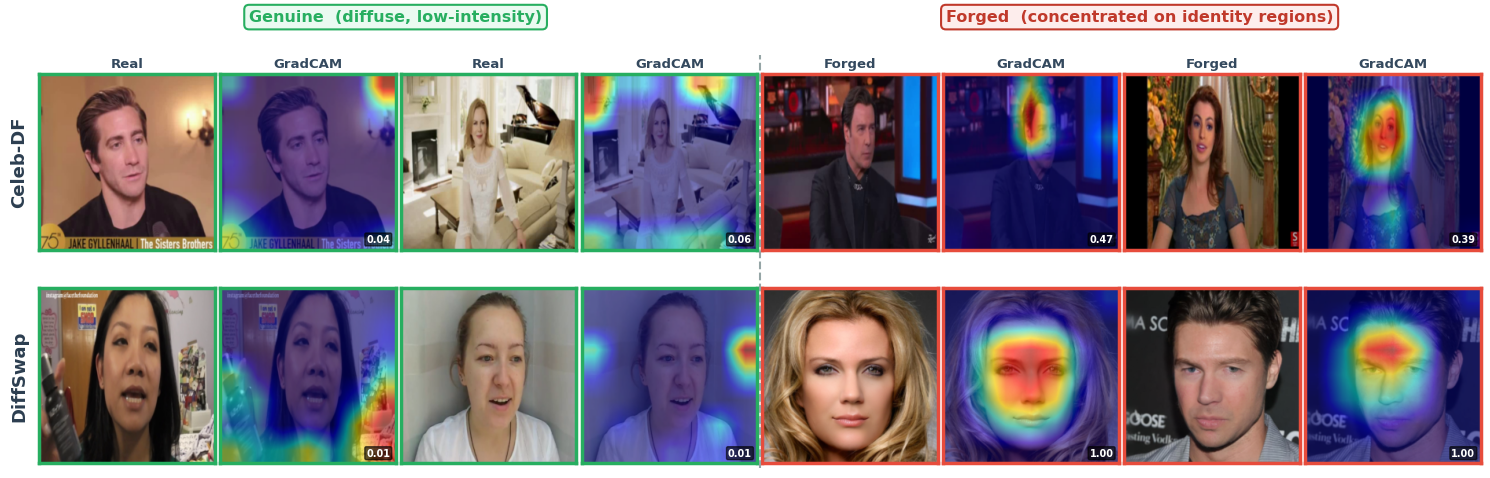


Saved: ./figures/gradcam.png
DONE!


In [1]:
"""
GradCAM Figure — Direct folder loading version
================================================
Loads images directly from your test folders.
No dataset class issues. Handles [0,255] images.
"""

# ============================================================
# CELL 1: Setup
# ============================================================
import os, glob, random, numpy as np, torch, torch.nn.functional as F
import matplotlib.pyplot as plt, cv2
from PIL import Image
from torchvision import transforms
from tqdm.auto import tqdm

DEVICE = "cuda:1" if torch.cuda.is_available() else "cpu"
device = torch.device(DEVICE)

# ---- YOUR FOLDER STRUCTURE (from the screenshot) ----
# Celeb-DF reals:
CELEBDF_REAL_DIRS = ["./test_images_celebdf/Celeb-real", "./test_images_celebdf/YouTube-real"]
# Celeb-DF fakes:
CELEBDF_FAKE_DIRS = ["./test_images_celebdf/Celeb-synthesis"]
# DiffSwap (only fakes):
DIFFSWAP_FAKE_DIRS = ["./test_images_diffswap/DiffSwap"]
# FF++ reals and fakes (for filling missing slots):
FFPP_REAL_DIRS = ["./test_images/original_sequences"]
FFPP_FAKE_DIRS = ["./test_images/manipulated_sequences"]
# DFD:
DFD_REAL_DIRS = ["./test_images_dfd/DFD_original_sequences"]
DFD_FAKE_DIRS = ["./test_images_dfd/DFD_manipulated_sequences"]

OUTPUT_PATH = "./figures/gradcam.png"

print(f"Device: {DEVICE}")


# ============================================================
# CELL 2: Load model
# ============================================================
import model as model_module
from lib.util import load_config

cfg = load_config("./configs/caddm_test.cfg")
net = model_module.get(backbone=cfg['model']['backbone'])
net = net.to(device)
ckpt = torch.load(cfg['model']['ckpt'], map_location=device)
net.load_state_dict(ckpt['network'])
net.eval()

TARGET_LAYER = net.base_model._blocks[-1]
print(f"Model: {cfg['model']['backbone']}, Target: _blocks[-1]")


# ============================================================
# CELL 3: Image loading helpers
# ============================================================
def find_images(dirs, exts=("*.jpg", "*.png", "*.jpeg", "*.bmp"), max_per_dir=200):
    """Find image files in directories (searches recursively)."""
    paths = []
    for d in dirs:
        if not os.path.exists(d):
            print(f"  WARNING: {d} does not exist")
            continue
        for ext in exts:
            found = glob.glob(os.path.join(d, "**", ext), recursive=True)
            paths.extend(found)
            if len(paths) >= max_per_dir * len(dirs):
                break
    random.shuffle(paths)
    return paths

def load_and_preprocess(img_path, size=224):
    """Load image, resize, convert to tensor for model input."""
    img = Image.open(img_path).convert("RGB")
    img = img.resize((size, size), Image.BILINEAR)
    img_np = np.array(img).astype(np.float32)  # (H, W, 3) in [0, 255]
    
    # Your model expects [0, 255] based on diagnostic:
    # min=0.0000, max=230.0000, mean=78.5529
    # So NO normalization needed — just convert to tensor
    img_tensor = torch.from_numpy(img_np).permute(2, 0, 1).unsqueeze(0)  # (1, 3, H, W)
    
    # For display: [0, 255] → [0, 1]
    img_display = img_np / 255.0
    
    return img_tensor, img_display

print("Helpers ready.")

# Verify folders exist
for name, dirs in [("CelebDF real", CELEBDF_REAL_DIRS), ("CelebDF fake", CELEBDF_FAKE_DIRS),
                   ("DiffSwap fake", DIFFSWAP_FAKE_DIRS), ("FFpp real", FFPP_REAL_DIRS),
                   ("FFpp fake", FFPP_FAKE_DIRS), ("DFD real", DFD_REAL_DIRS),
                   ("DFD fake", DFD_FAKE_DIRS)]:
    for d in dirs:
        exists = os.path.exists(d)
        count = len(glob.glob(os.path.join(d, "**", "*.jpg"), recursive=True)) + \
                len(glob.glob(os.path.join(d, "**", "*.png"), recursive=True)) if exists else 0
        status = f"OK ({count} images)" if exists else "MISSING"
        print(f"  {name:20s} {d:50s} {status}")


# ============================================================
# CELL 4: GradCAM
# ============================================================
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activation = None
        self.gradient = None
        self.hooks = [
            target_layer.register_forward_hook(self._fwd),
            target_layer.register_full_backward_hook(self._bwd),
        ]
    
    def _fwd(self, mod, inp, out):
        self.activation = (out[0] if isinstance(out, tuple) else out).detach()
    
    def _bwd(self, mod, gi, go):
        self.gradient = (go[0] if isinstance(go, tuple) else go).detach()
    
    def __call__(self, x):
        self.model.zero_grad()
        out = self.model(x)
        if isinstance(out, tuple):
            out = out[0]
        score = out[0, 1]  # fake probability
        score.backward(retain_graph=True)
        
        w = self.gradient.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((w * self.activation).sum(1, keepdim=True))
        cam = F.interpolate(cam, x.shape[2:], mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        mn, mx = cam.min(), cam.max()
        cam = (cam - mn) / (mx - mn + 1e-8)
        return cam, score.item()
    
    def remove(self):
        for h in self.hooks:
            h.remove()

def overlay_cam(img_01, cam, alpha=0.5):
    """Overlay heatmap on [0,1] image."""
    img_u8 = (np.clip(img_01, 0, 1) * 255).astype(np.uint8)
    hm = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
    hm = cv2.cvtColor(hm, cv2.COLOR_BGR2RGB)
    return cv2.addWeighted(img_u8, 1 - alpha, hm, alpha, 0)

print("GradCAM ready.")


# ============================================================
# CELL 5: Collect GradCAM samples from folders
# ============================================================
def collect_from_folders(real_dirs, fake_dirs, net, device, target_layer,
                         n_real=2, n_fake=2, label_name="Dataset"):
    """Load images from folders and compute GradCAM."""
    
    real_paths = find_images(real_dirs)
    fake_paths = find_images(fake_dirs)
    print(f"  {label_name}: {len(real_paths)} real images, {len(fake_paths)} fake images found")
    
    cam_ext = GradCAM(net, target_layer)
    
    reals = []
    fakes = []
    
    # Process reals
    if real_paths:
        for p in tqdm(real_paths[:50], desc=f"{label_name} real", leave=False):
            try:
                img_tensor, img_display = load_and_preprocess(p)
                x = img_tensor.to(device).requires_grad_(True)
                cam, score = cam_ext(x)
                reals.append({'image': img_display, 'cam': cam, 'score': score,
                              'label': 0, 'path': p})
            except Exception as e:
                continue
    
    # Process fakes
    if fake_paths:
        for p in tqdm(fake_paths[:50], desc=f"{label_name} fake", leave=False):
            try:
                img_tensor, img_display = load_and_preprocess(p)
                x = img_tensor.to(device).requires_grad_(True)
                cam, score = cam_ext(x)
                fakes.append({'image': img_display, 'cam': cam, 'score': score,
                              'label': 1, 'path': p})
            except Exception as e:
                continue
    
    cam_ext.remove()
    
    # Sort: reals by lowest score (most confident real), fakes by highest
    reals.sort(key=lambda e: e['score'])
    fakes.sort(key=lambda e: e['score'], reverse=True)
    
    # Pick best n from different parent folders
    def pick(entries, n):
        seen, picked = set(), []
        for e in entries:
            parent = os.path.dirname(e['path'])
            if parent not in seen:
                picked.append(e)
                seen.add(parent)
            if len(picked) >= n:
                break
        while len(picked) < n and len(entries) > len(picked):
            for e in entries:
                if e not in picked:
                    picked.append(e)
                    break
        return picked[:n]
    
    best_r = pick(reals, n_real)
    best_f = pick(fakes, n_fake)
    
    for r in best_r:
        print(f"    REAL picked: score={r['score']:.4f}, path={os.path.basename(r['path'])}")
    for f in best_f:
        print(f"    FAKE picked: score={f['score']:.4f}, path={os.path.basename(f['path'])}")
    
    return best_r, best_f


# ============================================================
# CELL 6: Collect from all three datasets
# ============================================================
random.seed(42)

# --- Celeb-DF ---
print("\n=== Celeb-DF ===")
celebdf_r, celebdf_f = collect_from_folders(
    CELEBDF_REAL_DIRS, CELEBDF_FAKE_DIRS, net, device, TARGET_LAYER,
    n_real=2, n_fake=2, label_name="Celeb-DF"
)

# --- DiffSwap (has no reals — use FF++ or DFD reals instead) ---
print("\n=== DiffSwap ===")
# DiffSwap only has fakes, so get fakes from DiffSwap and reals from FF++
diffswap_r_tmp, diffswap_f = collect_from_folders(
    FFPP_REAL_DIRS,       # Use FF++ reals since DiffSwap has none
    DIFFSWAP_FAKE_DIRS,
    net, device, TARGET_LAYER,
    n_real=2, n_fake=2, label_name="DiffSwap"
)
# Use FF++ reals as the "real" baseline for DiffSwap row
diffswap_r = diffswap_r_tmp

# --- FF++ (backup) ---
print("\n=== FF++ (backup) ===")
ffpp_r, ffpp_f = collect_from_folders(
    FFPP_REAL_DIRS, FFPP_FAKE_DIRS, net, device, TARGET_LAYER,
    n_real=2, n_fake=2, label_name="FF++"
)


# ============================================================
# CELL 7: Preview collected samples
# ============================================================
def preview(samples, title):
    n = len(samples)
    if n == 0:
        print(f"NO SAMPLES: {title}")
        return
    fig, axes = plt.subplots(2, n, figsize=(4 * n, 7))
    if n == 1:
        axes = axes.reshape(2, 1)
    fig.suptitle(title, fontsize=14, fontweight='bold')
    for j, s in enumerate(samples):
        axes[0, j].imshow(s['image'])
        axes[0, j].set_title(f"score={s['score']:.3f}", fontsize=9)
        axes[0, j].axis('off')
        axes[1, j].imshow(overlay_cam(s['image'], s['cam']))
        axes[1, j].set_title("GradCAM", fontsize=9)
        axes[1, j].axis('off')
    plt.tight_layout()
    plt.show()

preview(celebdf_r, "Celeb-DF REAL")
preview(celebdf_f, "Celeb-DF FAKE")
preview(diffswap_r, "DiffSwap REAL (from FF++)")
preview(diffswap_f, "DiffSwap FAKE")


# ============================================================
# CELL 8: Generate the final paper figure
# ============================================================
def make_figure(cr, cf, dr, df, path):
    fig, axes = plt.subplots(2, 8, figsize=(15.5, 4.8))
    plt.subplots_adjust(wspace=0.03, hspace=0.10,
                        left=0.05, right=0.98, top=0.86, bottom=0.01)
    
    rows = [('Celeb-DF', cr, cf), ('DiffSwap', dr, df)]
    
    for row, (dsname, reals, fakes) in enumerate(rows):
        while len(reals) < 2:
            reals.append(None)
        while len(fakes) < 2:
            fakes.append(None)
        
        items = [('real', reals[0]), ('real', reals[1]),
                 ('fake', fakes[0]), ('fake', fakes[1])]
        
        for pidx, (stype, entry) in enumerate(items):
            c1 = pidx * 2
            c2 = pidx * 2 + 1
            bc = '#27ae60' if stype == 'real' else '#e74c3c'
            
            ax1 = axes[row, c1]
            ax2 = axes[row, c2]
            
            if entry is not None:
                ax1.imshow(entry['image'])
                ov = overlay_cam(entry['image'], entry['cam'], alpha=0.50)
                ax2.imshow(ov)
                ax2.text(0.97, 0.03, f'{entry["score"]:.2f}',
                        transform=ax2.transAxes, fontsize=7,
                        ha='right', va='bottom', color='white', fontweight='bold',
                        bbox=dict(boxstyle='round,pad=0.15', fc='black', alpha=0.6))
            else:
                ax1.text(0.5, 0.5, 'N/A', transform=ax1.transAxes,
                        ha='center', va='center', fontsize=14, color='gray')
                ax2.text(0.5, 0.5, 'N/A', transform=ax2.transAxes,
                        ha='center', va='center', fontsize=14, color='gray')
            
            for ax in [ax1, ax2]:
                ax.set_xticks([])
                ax.set_yticks([])
                for sp in ax.spines.values():
                    sp.set_color(bc)
                    sp.set_linewidth(2.5)
        
        axes[row, 0].set_ylabel(dsname, fontsize=13, fontweight='bold',
                                color='#2c3e50', labelpad=8)
    
    for i, h in enumerate(['Real', 'GradCAM', 'Real', 'GradCAM',
                           'Forged', 'GradCAM', 'Forged', 'GradCAM']):
        axes[0, i].set_title(h, fontsize=9.5, fontweight='bold', color='#34495e', pad=5)
    
    fig.text(0.28, 0.95, 'Genuine  (diffuse, low-intensity)',
             ha='center', fontsize=11.5, fontweight='bold', color='#27ae60',
             bbox=dict(boxstyle='round,pad=0.3', fc='#eafaf1', ec='#27ae60', lw=1.5))
    fig.text(0.76, 0.95, 'Forged  (concentrated on identity regions)',
             ha='center', fontsize=11.5, fontweight='bold', color='#c0392b',
             bbox=dict(boxstyle='round,pad=0.3', fc='#fdedec', ec='#c0392b', lw=1.5))
    fig.add_artist(plt.Line2D([0.515, 0.515], [0.02, 0.88],
                               transform=fig.transFigure, color='#95a5a6', lw=1.5, ls='--'))
    
    os.makedirs(os.path.dirname(path) or '.', exist_ok=True)
    fig.savefig(path, dpi=220, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"\nSaved: {path}")

make_figure(celebdf_r, celebdf_f, diffswap_r, diffswap_f, OUTPUT_PATH)
print("DONE!")

In [1]:
#!/usr/bin/env python3
"""
GradCAM Figure Generator for DIMF Paper
========================================
Generates figures/gradcam.png for the paper.

Usage (Jupyter or terminal):
    python generate_gradcam_figure.py \
        --cfg ./configs/caddm_test.cfg \
        --celebdf_cfg ./configs/caddm_test_celebdf.cfg \
        --diffswap_cfg ./configs/caddm_test_diffswap.cfg \
        --output ./figures/gradcam.png

Or in Jupyter, just set the paths in the CONFIG section below and run all cells.
"""

import os
import sys
import argparse
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from torch.utils.data import DataLoader
from PIL import Image
import cv2

# ============================================================
# CONFIG — Edit these paths if running in Jupyter
# ============================================================
# If running as script, these are overridden by argparse
DEFAULT_CFG = "./configs/caddm_test.cfg"
DEFAULT_CELEBDF_CFG = "./configs/caddm_test_celebdf.cfg"  
DEFAULT_DIFFSWAP_CFG = "./configs/caddm_test_diffswap.cfg"
DEFAULT_OUTPUT = "./figures/gradcam.png"
DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"

# Number of real/fake samples per dataset row
N_REAL = 2
N_FAKE = 2


# ============================================================
# 1. MODEL LOADING (from your existing code)
# ============================================================
import model as model_module
from dataset import DeepfakeDataset
from lib.util import load_config


def load_model(cfg_path):
    """Load your trained model from config."""
    cfg = load_config(cfg_path)
    net = model_module.get(backbone=cfg['model']['backbone'])
    device = torch.device(DEVICE)
    net = net.to(device)
    
    if cfg['model']['ckpt']:
        checkpoint = torch.load(cfg['model']['ckpt'], map_location=device)
        net.load_state_dict(checkpoint['network'])
        print(f"Loaded checkpoint: {cfg['model']['ckpt']}")
    
    net.eval()
    return net, cfg, device


def get_target_layer(net):
    """
    Find the last convolutional layer for GradCAM.
    Adjust this based on your actual model architecture.
    """
    # --- Option A: If your model has a .backbone attribute (ConvNeXt-V2) ---
    if hasattr(net, 'backbone'):
        if hasattr(net.backbone, 'stages'):
            # ConvNeXt-V2: last stage, last block
            return [net.backbone.stages[-1]]
        elif hasattr(net.backbone, 'features'):
            # EfficientNet via timm: last feature block
            return [net.backbone.features[-1]]
    
    # --- Option B: If using efficientnet_pytorch ---
    if hasattr(net, 'efficientnet') or hasattr(net, 'net'):
        backbone = getattr(net, 'efficientnet', getattr(net, 'net', None))
        if backbone is not None:
            if hasattr(backbone, '_blocks'):
                # efficientnet_pytorch: last MBConv block
                return [backbone._blocks[-1]]
            if hasattr(backbone, 'features'):
                return [backbone.features[-1]]
    
    # --- Option C: Search for it ---
    # Walk all modules, pick the last Conv2d or last Sequential block
    last_conv = None
    last_sequential = None
    for name, module in net.named_modules():
        if isinstance(module, torch.nn.Conv2d):
            last_conv = module
            last_conv_name = name
        if isinstance(module, torch.nn.Sequential) and len(list(module.children())) > 0:
            last_sequential = module
    
    if last_conv is not None:
        print(f"Auto-detected target layer: {last_conv_name}")
        return [last_conv]
    
    raise RuntimeError(
        "Could not auto-detect the target layer. "
        "Please manually set it by inspecting your model with:\n"
        "  for name, module in net.named_modules(): print(name, type(module))"
    )


# ============================================================
# 2. GradCAM IMPLEMENTATION (self-contained, no pip install needed)
# ============================================================
class GradCAM:
    """
    Minimal GradCAM implementation. No external dependencies needed.
    Works with any model that has a convolutional target layer.
    """
    def __init__(self, model, target_layers):
        self.model = model
        self.target_layers = target_layers
        self.activations = {}
        self.gradients = {}
        self._register_hooks()
    
    def _register_hooks(self):
        for i, layer in enumerate(self.target_layers):
            layer.register_forward_hook(self._save_activation(i))
            layer.register_full_backward_hook(self._save_gradient(i))
    
    def _save_activation(self, idx):
        def hook(module, input, output):
            # Handle case where output is a tuple
            if isinstance(output, tuple):
                output = output[0]
            self.activations[idx] = output.detach()
        return hook
    
    def _save_gradient(self, idx):
        def hook(module, grad_input, grad_output):
            if isinstance(grad_output, tuple):
                self.gradients[idx] = grad_output[0].detach()
            else:
                self.gradients[idx] = grad_output.detach()
        return hook
    
    def __call__(self, input_tensor, target_class=None):
        """
        Args:
            input_tensor: (1, C, H, W) tensor
            target_class: int or None. If None, uses the predicted class.
        Returns:
            cam: (H, W) numpy array, normalized to [0, 1]
        """
        self.model.zero_grad()
        
        # Forward pass
        output = self.model(input_tensor)
        
        # Handle different output formats
        if isinstance(output, tuple):
            output = output[0]  # Take first element if tuple
        
        if output.dim() == 1:
            logits = output
        elif output.shape[-1] == 2:
            # Binary classification with 2 outputs: take fake class
            logits = output[:, 1]
        elif output.shape[-1] == 1:
            logits = output.squeeze(-1)
        else:
            logits = output[:, 1] if output.shape[-1] > 1 else output.squeeze(-1)
        
        # Get prediction score for the target (fake) class
        if target_class is not None:
            score = output[:, target_class]
        else:
            score = logits
        
        # Backward pass
        score.backward(retain_graph=True)
        
        # Compute CAM
        cams = []
        for idx in range(len(self.target_layers)):
            activation = self.activations[idx]  # (1, C, h, w)
            gradient = self.gradients[idx]       # (1, C, h, w)
            
            # Global average pooling of gradients
            weights = gradient.mean(dim=(2, 3), keepdim=True)  # (1, C, 1, 1)
            
            # Weighted combination
            cam = (weights * activation).sum(dim=1, keepdim=True)  # (1, 1, h, w)
            cam = F.relu(cam)  # ReLU to keep only positive contributions
            
            # Resize to input size
            cam = F.interpolate(cam, size=input_tensor.shape[2:], 
                               mode='bilinear', align_corners=False)
            cam = cam.squeeze().cpu().numpy()
            
            # Normalize to [0, 1]
            cam_min, cam_max = cam.min(), cam.max()
            if cam_max - cam_min > 1e-8:
                cam = (cam - cam_min) / (cam_max - cam_min)
            else:
                cam = np.zeros_like(cam)
            
            cams.append(cam)
        
        return cams[0]  # Return first target layer's CAM


def apply_colormap(image_rgb, cam, alpha=0.5):
    """
    Overlay GradCAM heatmap on the original image.
    
    Args:
        image_rgb: (H, W, 3) numpy array, float [0, 1] or uint8 [0, 255]
        cam: (H, W) numpy array, float [0, 1]
        alpha: overlay strength
    Returns:
        blended: (H, W, 3) numpy array, uint8
    """
    if image_rgb.dtype == np.float32 or image_rgb.dtype == np.float64:
        img = (image_rgb * 255).astype(np.uint8)
    else:
        img = image_rgb.copy()
    
    # Apply JET colormap to heatmap
    heatmap = cv2.applyColorMap((cam * 255).astype(np.uint8), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    
    # Blend
    blended = cv2.addWeighted(img, 1.0 - alpha, heatmap, alpha, 0)
    return blended


# ============================================================
# 3. SAMPLE COLLECTION
# ============================================================
def collect_samples(cfg, net, device, n_real=2, n_fake=2, seed=42):
    """
    Collect n_real genuine and n_fake forged samples from a dataset.
    Returns list of dicts with 'image', 'label', 'score', 'cam'.
    """
    dataset = DeepfakeDataset('test', cfg)
    loader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=2)
    
    cam_extractor = GradCAM(net, get_target_layer(net))
    
    reals = []
    fakes = []
    
    rng = np.random.RandomState(seed)
    # We'll collect more than needed, then sample
    all_reals = []
    all_fakes = []
    
    print(f"  Scanning dataset ({cfg['dataset']['name']})...")
    
    with torch.enable_grad():
        for i, (batch_data, batch_labels) in enumerate(loader):
            labels, video_name = batch_labels
            label = labels.item()
            
            img_tensor = batch_data.to(device)
            img_tensor.requires_grad_(True)
            
            # Get GradCAM
            try:
                cam = cam_extractor(img_tensor, target_class=1)  # class 1 = fake
            except Exception as e:
                # If target_class doesn't work, try without
                try:
                    cam = cam_extractor(img_tensor, target_class=None)
                except:
                    print(f"  Skipping sample {i} due to error: {e}")
                    continue
            
            # Get the original image as numpy (reverse normalization if needed)
            img_np = batch_data[0].permute(1, 2, 0).cpu().numpy()
            # If normalized (values roughly in [-2, 2]), reverse it
            if img_np.min() < -0.5:
                # Assume ImageNet normalization
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img_np = img_np * std + mean
            img_np = np.clip(img_np, 0, 1)
            
            # Get score
            with torch.no_grad():
                output = net(img_tensor)
                if isinstance(output, tuple):
                    output = output[0]
                if output.shape[-1] == 2:
                    score = torch.softmax(output, dim=-1)[0, 1].item()
                else:
                    score = torch.sigmoid(output).item()
            
            entry = {
                'image': img_np,     # (H, W, 3) float [0,1]
                'cam': cam,          # (H, W) float [0,1]
                'label': label,
                'score': score,
                'video': video_name[0] if isinstance(video_name, (list, tuple)) else str(video_name),
            }
            
            if label == 0:
                all_reals.append(entry)
            else:
                all_fakes.append(entry)
            
            # Collect enough candidates
            if len(all_reals) >= n_real * 5 and len(all_fakes) >= n_fake * 5:
                break
            
            # Safety cap
            if i > 500:
                break
    
    print(f"  Collected {len(all_reals)} real, {len(all_fakes)} fake candidates")
    
    # Select diverse samples (from different videos if possible)
    def select_diverse(entries, n):
        if len(entries) <= n:
            return entries[:n] if len(entries) >= n else entries
        
        # Try to pick from different videos
        seen_videos = set()
        selected = []
        for e in entries:
            if e['video'] not in seen_videos and len(selected) < n:
                selected.append(e)
                seen_videos.add(e['video'])
        
        # Fill remaining randomly
        remaining = [e for e in entries if e['video'] not in seen_videos]
        while len(selected) < n and remaining:
            idx = rng.randint(0, len(remaining))
            selected.append(remaining.pop(idx))
        
        # If still not enough, just take first ones
        while len(selected) < n:
            selected.append(entries[len(selected)])
        
        return selected
    
    reals = select_diverse(all_reals, n_real)
    fakes = select_diverse(all_fakes, n_fake)
    
    return reals, fakes


# ============================================================
# 4. FIGURE GENERATION
# ============================================================
def generate_figure(celebdf_reals, celebdf_fakes, 
                    diffswap_reals, diffswap_fakes, 
                    output_path):
    """
    Generate the final 2-row × 8-column GradCAM figure.
    
    Layout per row:
      [Real1] [CAM1] [Real2] [CAM2] | [Fake1] [CAM1] [Fake2] [CAM2]
    """
    fig, axes = plt.subplots(2, 8, figsize=(15.5, 4.8))
    plt.subplots_adjust(wspace=0.03, hspace=0.10, 
                        left=0.05, right=0.98, top=0.86, bottom=0.01)
    
    datasets = [
        ('Celeb-DF', celebdf_reals, celebdf_fakes),
        ('DiffSwap', diffswap_reals, diffswap_fakes),
    ]
    
    for row, (ds_name, reals, fakes) in enumerate(datasets):
        # Columns: R1, CAM1, R2, CAM2, F1, CAM1, F2, CAM2
        samples = []
        for r in reals[:2]:
            samples.append(('real', r))
        for f in fakes[:2]:
            samples.append(('fake', f))
        
        for pair_idx, (stype, entry) in enumerate(samples):
            col_face = pair_idx * 2
            col_cam = pair_idx * 2 + 1
            
            img = entry['image']
            cam = entry['cam']
            overlay_img = apply_colormap(img, cam, alpha=0.50)
            
            # Border color
            bc = '#27ae60' if stype == 'real' else '#e74c3c'
            
            # Original face
            ax = axes[row, col_face]
            ax.imshow(img)
            ax.set_xticks([]); ax.set_yticks([])
            for sp in ax.spines.values():
                sp.set_color(bc); sp.set_linewidth(2.5)
            
            # GradCAM overlay
            ax2 = axes[row, col_cam]
            ax2.imshow(overlay_img)
            ax2.set_xticks([]); ax2.set_yticks([])
            for sp in ax2.spines.values():
                sp.set_color(bc); sp.set_linewidth(2.5)
            
            # Score annotation on CAM image
            ax2.text(0.97, 0.03, f'{entry["score"]:.2f}', 
                    transform=ax2.transAxes, fontsize=7,
                    ha='right', va='bottom',
                    color='white', fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.15', fc='black', alpha=0.6))
        
        # Row label
        axes[row, 0].set_ylabel(ds_name, fontsize=13, fontweight='bold',
                                color='#2c3e50', labelpad=8)
    
    # Column headers
    headers = ['Real', 'GradCAM', 'Real', 'GradCAM', 
               'Forged', 'GradCAM', 'Forged', 'GradCAM']
    for i, h in enumerate(headers):
        axes[0, i].set_title(h, fontsize=9.5, fontweight='bold', 
                            color='#34495e', pad=5)
    
    # Group labels
    fig.text(0.28, 0.95, 'Genuine  (diffuse, low-intensity)', 
             ha='center', fontsize=11.5, fontweight='bold', color='#27ae60',
             bbox=dict(boxstyle='round,pad=0.3', fc='#eafaf1', ec='#27ae60', lw=1.5))
    fig.text(0.76, 0.95, 'Forged  (concentrated on identity regions)', 
             ha='center', fontsize=11.5, fontweight='bold', color='#c0392b',
             bbox=dict(boxstyle='round,pad=0.3', fc='#fdedec', ec='#c0392b', lw=1.5))
    
    # Dashed divider
    fig.add_artist(plt.Line2D([0.515, 0.515], [0.02, 0.88], 
                               transform=fig.transFigure,
                               color='#95a5a6', lw=1.5, ls='--'))
    
    # Save
    os.makedirs(os.path.dirname(output_path) or '.', exist_ok=True)
    fig.savefig(output_path, dpi=220, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f"\nSaved figure to: {output_path}")


# ============================================================
# 5. MAIN
# ============================================================
def main():
    parser = argparse.ArgumentParser(description='Generate GradCAM figure for DIMF paper')
    parser.add_argument('--cfg', type=str, default=DEFAULT_CFG,
                        help='Base config (for model loading)')
    parser.add_argument('--celebdf_cfg', type=str, default=DEFAULT_CELEBDF_CFG,
                        help='Config for Celeb-DF test set')
    parser.add_argument('--diffswap_cfg', type=str, default=DEFAULT_DIFFSWAP_CFG,
                        help='Config for DiffSwap test set')
    parser.add_argument('--output', type=str, default=DEFAULT_OUTPUT,
                        help='Output path for the figure')
    parser.add_argument('--seed', type=int, default=42)
    args = parser.parse_args()
    
    # Load model once
    print("Loading model...")
    net, base_cfg, device = load_model(args.cfg)
    
    # Print model structure to help identify target layer
    print("\nModel structure (top-level modules):")
    for name, module in net.named_children():
        print(f"  {name}: {type(module).__name__}")
    
    target = get_target_layer(net)
    print(f"\nTarget layer for GradCAM: {target}")
    
    # Collect samples from Celeb-DF
    print("\n--- Celeb-DF ---")
    celebdf_cfg = load_config(args.celebdf_cfg)
    celebdf_reals, celebdf_fakes = collect_samples(
        celebdf_cfg, net, device, n_real=N_REAL, n_fake=N_FAKE, seed=args.seed
    )
    
    # Collect samples from DiffSwap
    print("\n--- DiffSwap ---")
    diffswap_cfg = load_config(args.diffswap_cfg)
    diffswap_reals, diffswap_fakes = collect_samples(
        diffswap_cfg, net, device, n_real=N_REAL, n_fake=N_FAKE, seed=args.seed + 1
    )
    
    # Generate figure
    print("\nGenerating figure...")
    generate_figure(celebdf_reals, celebdf_fakes,
                    diffswap_reals, diffswap_fakes,
                    args.output)
    
    print("Done!")


if __name__ == "__main__":
    main()


# ============================================================
# 6. JUPYTER NOTEBOOK VERSION
#    Copy everything below into a notebook cell if preferred
# ============================================================
"""
# --- Cell 1: Setup ---
%matplotlib inline
import torch
import numpy as np

# Set your paths here:
CFG_PATH = "./configs/caddm_test.cfg"
CELEBDF_CFG_PATH = "./configs/caddm_test_celebdf.cfg"
DIFFSWAP_CFG_PATH = "./configs/caddm_test_diffswap.cfg"
OUTPUT_PATH = "./figures/gradcam.png"
DEVICE = "cuda:0"

# --- Cell 2: Load model ---
net, base_cfg, device = load_model(CFG_PATH)

# Check structure:
for name, module in net.named_children():
    print(f"  {name}: {type(module).__name__}")

# --- Cell 3: Verify target layer ---
target = get_target_layer(net)
print(f"Target layer: {target}")

# If this picks the wrong layer, manually set it:
# target = [net.YOUR_MODULE.YOUR_LAYER]

# --- Cell 4: Collect Celeb-DF samples ---
celebdf_cfg = load_config(CELEBDF_CFG_PATH)
celebdf_reals, celebdf_fakes = collect_samples(
    celebdf_cfg, net, device, n_real=2, n_fake=2, seed=42
)
print(f"Celeb-DF: {len(celebdf_reals)} real, {len(celebdf_fakes)} fake")

# --- Cell 5: Collect DiffSwap samples ---
diffswap_cfg = load_config(DIFFSWAP_CFG_PATH)
diffswap_reals, diffswap_fakes = collect_samples(
    diffswap_cfg, net, device, n_real=2, n_fake=2, seed=43
)
print(f"DiffSwap: {len(diffswap_reals)} real, {len(diffswap_fakes)} fake")

# --- Cell 6: Quick preview of one sample ---
import matplotlib.pyplot as plt
sample = celebdf_fakes[0]
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))
ax1.imshow(sample['image']); ax1.set_title(f"Original (label={sample['label']})")
ax2.imshow(sample['cam'], cmap='jet'); ax2.set_title("GradCAM heatmap")
overlay = apply_colormap(sample['image'], sample['cam'])
ax3.imshow(overlay); ax3.set_title(f"Overlay (score={sample['score']:.3f})")
for ax in [ax1, ax2, ax3]: ax.axis('off')
plt.tight_layout(); plt.show()

# --- Cell 7: Generate final figure ---
generate_figure(celebdf_reals, celebdf_fakes,
                diffswap_reals, diffswap_fakes,
                OUTPUT_PATH)
"""

usage: ipykernel_launcher.py [-h] [--cfg CFG] [--celebdf_cfg CELEBDF_CFG]
                             [--diffswap_cfg DIFFSWAP_CFG] [--output OUTPUT]
                             [--seed SEED]
ipykernel_launcher.py: error: unrecognized arguments: --f=/run/user/1009/jupyter/runtime/kernel-v392f82f5d277923e8dc0bdc65d39a2b08a531595e.json


SystemExit: 2

/scratch/sahil/anaconda3/envs/dif/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [5]:
"""
Params & FLOPs for CADDM model — Jupyter version
=================================================
Just run all cells.
"""

# ============================================================
# CELL 1: Setup
# ============================================================
import torch
import torch.nn as nn
import time

DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
CFG_PATH = "./configs/caddm_test.cfg"
INPUT_SIZE = (1, 3, 224, 224)  # your model uses 224x224

print(f"Device: {DEVICE}")


# ============================================================
# CELL 2: Load model
# ============================================================
import model as model_module
from lib.util import load_config

cfg = load_config(CFG_PATH)
net = model_module.get(backbone=cfg['model']['backbone'])
device = torch.device(DEVICE)
net = net.to(device)

ckpt = torch.load(cfg['model']['ckpt'], map_location=device)
net.load_state_dict(ckpt['network'])
net.eval()
print(f"Loaded: {cfg['model']['backbone']}")


# ============================================================
# CELL 3: Parameter count
# ============================================================
total_params = sum(p.numel() for p in net.parameters())
trainable_params = sum(p.numel() for p in net.parameters() if p.requires_grad)

print(f"\nTotal params:     {total_params:,} ({total_params/1e6:.2f}M)")
print(f"Trainable params: {trainable_params:,} ({trainable_params/1e6:.2f}M)")

print("\nPer-module breakdown:")
print("-" * 45)
for name, child in net.named_children():
    n = sum(p.numel() for p in child.parameters())
    print(f"  {name:30s} {n/1e6:8.2f}M  ({n:,})")


# ============================================================
# CELL 4: FLOPs — manual hook counting (no pip install needed)
# ============================================================
total_flops = [0]
hooks = []

def conv_hook(module, inp, out):
    b = inp[0].shape[0]
    c_out, h_out, w_out = out.shape[1], out.shape[2], out.shape[3]
    c_in = module.in_channels // module.groups
    k = module.kernel_size[0] * module.kernel_size[1]
    total_flops[0] += 2 * b * c_out * h_out * w_out * c_in * k

def linear_hook(module, inp, out):
    b = inp[0].shape[0]
    total_flops[0] += 2 * b * module.in_features * module.out_features

def bn_hook(module, inp, out):
    total_flops[0] += 2 * inp[0].numel()

for m in net.modules():
    if isinstance(m, nn.Conv2d):
        hooks.append(m.register_forward_hook(conv_hook))
    elif isinstance(m, nn.Linear):
        hooks.append(m.register_forward_hook(linear_hook))
    elif isinstance(m, (nn.BatchNorm2d, nn.LayerNorm, nn.GroupNorm)):
        hooks.append(m.register_forward_hook(bn_hook))

x = torch.randn(*INPUT_SIZE).to(device)
with torch.no_grad():
    net(x)

for h in hooks:
    h.remove()

print(f"\nFLOPs (manual):  {total_flops[0]:,} ({total_flops[0]/1e9:.2f}G)")


# ============================================================
# CELL 5: FLOPs — fvcore (more accurate, install if available)
# ============================================================
try:
    from fvcore.nn import FlopCountAnalysis
    x = torch.randn(*INPUT_SIZE).to(device)
    flops = FlopCountAnalysis(net, x)
    print(f"FLOPs (fvcore):  {flops.total():,} ({flops.total()/1e9:.2f}G)")
except ImportError:
    print("fvcore not installed. Run: pip install fvcore")
except Exception as e:
    print(f"fvcore error: {e}")

try:
    from thop import profile
    x = torch.randn(*INPUT_SIZE).to(device)
    flops, params = profile(net, inputs=(x,), verbose=False)
    print(f"FLOPs (thop):    {flops:,.0f} ({flops/1e9:.2f}G)")
    print(f"Params (thop):   {params:,.0f} ({params/1e6:.2f}M)")
except ImportError:
    print("thop not installed. Run: pip install thop")
except Exception as e:
    print(f"thop error: {e}")


# ============================================================
# CELL 6: Inference speed
# ============================================================
x = torch.randn(*INPUT_SIZE).to(device)

with torch.no_grad():
    for _ in range(20):
        net(x)
if device.type == 'cuda':
    torch.cuda.synchronize()

N = 100
with torch.no_grad():
    if device.type == 'cuda':
        torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(N):
        net(x)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    t1 = time.time()

ms = (t1 - t0) / N * 1000
print(f"\nInference: {ms:.2f} ms/image, {1000/ms:.1f} images/sec ({device})")


# ============================================================
# CELL 7: Summary
# ============================================================
print("\n" + "=" * 50)
print("SUMMARY")
print("=" * 50)
print(f"  Model:       {cfg['model']['backbone']}")
print(f"  Input:       {INPUT_SIZE[2]}x{INPUT_SIZE[3]}")
print(f"  Params:      {total_params/1e6:.2f}M")
print(f"  FLOPs:       {total_flops[0]/1e9:.2f}G")
print(f"  Speed:       {ms:.2f} ms ({1000/ms:.1f} img/s)")
print("=" * 50)

Device: cuda:0
Loaded: efficientnet-b4

Total params:     289,736,546 (289.74M)
Trainable params: 289,736,546 (289.74M)

Per-module breakdown:
---------------------------------------------
  base_model                        19.34M  (19,341,616)
  adm                              270.39M  (270,391,344)
  fc                                 0.00M  (3,586)
  softmax                            0.00M  (0)

FLOPs (manual):  12,550,589,632 (12.55G)


Unsupported operator aten::pad encountered 33 time(s)
Unsupported operator prim::PythonOp.SwishImplementation encountered 96 time(s)
Unsupported operator aten::sigmoid encountered 32 time(s)
Unsupported operator aten::mul encountered 32 time(s)
Unsupported operator aten::add encountered 26 time(s)
Unsupported operator aten::add_ encountered 4 time(s)
Unsupported operator aten::softmax encountered 1 time(s)
The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
adm.multi_scale_detection_module, adm.multi_scale_detection_module.ms_cls.0, adm.multi_scale_detection_module.ms_cls.1, adm.multi_scale_detection_module.ms_cls.2, adm.multi_scale_detection_module.ms_cls.3, adm.multi_scale_detection_module.ms_dets.0, adm.multi_scale_de

FLOPs (fvcore):  6,283,477,088 (6.28G)
thop not installed. Run: pip install thop

Inference: 18.36 ms/image, 54.5 images/sec (cuda:0)

SUMMARY
  Model:       efficientnet-b4
  Input:       224x224
  Params:      289.74M
  FLOPs:       12.55G
  Speed:       18.36 ms (54.5 img/s)


In [ ]:
"""
Transformer SMC Variant — Parameter & FLOPs Counter
=====================================================
Drop-in replacement for MambaFakeHead's SMC branch using a standard
Transformer encoder instead of BiMamba, for verifying Table 5 claims.

Same: 7×7 tokenization, d=512, L=2 layers, pool→proj→blocks→LN→mean→MLP
Different: Transformer encoder layers instead of BiMamba blocks

Run:
  python dimf_transformer_counter.py

Compare output with Mamba results to verify:
  - Paper Table 5: Transformer = 96M params, 21.2G FLOPs
  - Paper Table 5: Mamba      = 88M params, 19.4G FLOPs
"""

import torch
import torch.nn as nn
import math
from collections import OrderedDict


# ═══════════════════════════════════════════════════════════════
# Transformer SMC (replaces BiMamba blocks with TransformerEncoder)
# ═══════════════════════════════════════════════════════════════

class TransformerSMC(nn.Module):
    """SMC with standard Transformer encoder instead of BiMamba.
    
    Matches paper spec (§5.3.1): identical 7×7 tokenization,
    hidden width (d=512), depth (L=2), and training protocol.
    Uses standard nn.TransformerEncoderLayer with:
      - d_model=512, nhead=8, dim_feedforward=2048, dropout=0.1
    """
    def __init__(self, D=1792, d=512, L=2, nhead=8, dim_ff=2048, dropout=0.1):
        super().__init__()
        self.proj = nn.Linear(D, d)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d,
            nhead=nhead,
            dim_feedforward=dim_ff,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True  # pre-norm like typical vision transformers
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=L)
        
        self.norm = nn.LayerNorm(d)
        self.classifier = nn.Sequential(
            nn.Linear(d, d // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d // 2, 1)
        )
        
        # Learnable position embedding for 7×7=49 tokens
        self.pos_embed = nn.Parameter(torch.randn(1, 49, d) * 0.02)
    
    def forward(self, f):
        B = f.shape[0]
        pooled = nn.functional.adaptive_avg_pool2d(f, (7, 7))
        tokens = pooled.flatten(2).transpose(1, 2)  # (B, 49, D)
        tokens = self.proj(tokens)  # (B, 49, d)
        tokens = tokens + self.pos_embed
        tokens = self.encoder(tokens)
        tokens = self.norm(tokens)
        pooled = tokens.mean(dim=1)
        return self.classifier(pooled)


# ═══════════════════════════════════════════════════════════════
# Transformer DIMF variant (for completeness)
# ═══════════════════════════════════════════════════════════════

class TransformerDIMFBranch(nn.Module):
    """DIMF branch with Transformer instead of BiMamba per-stream.
    Same structure: per-stream processing → symmetric cross-attention → MLP.
    """
    def __init__(self, D=1792, d=512, L_prime=1, nhead=8, dim_ff=2048, dropout=0.1):
        super().__init__()
        self.proj_s = nn.Linear(D, d)
        self.proj_t = nn.Linear(D, d)
        
        encoder_layer_s = nn.TransformerEncoderLayer(
            d_model=d, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True
        )
        encoder_layer_t = nn.TransformerEncoderLayer(
            d_model=d, nhead=nhead, dim_feedforward=dim_ff,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True
        )
        self.encoder_s = nn.TransformerEncoder(encoder_layer_s, num_layers=L_prime)
        self.encoder_t = nn.TransformerEncoder(encoder_layer_t, num_layers=L_prime)
        
        self.cross_attn_s = nn.MultiheadAttention(d, nhead, dropout=dropout, batch_first=True)
        self.cross_attn_t = nn.MultiheadAttention(d, nhead, dropout=dropout, batch_first=True)
        self.norm_s = nn.LayerNorm(d)
        self.norm_t = nn.LayerNorm(d)
        
        self.pos_embed = nn.Parameter(torch.randn(1, 49, d) * 0.02)
        
        self.classifier = nn.Sequential(
            nn.Linear(2 * d, d),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d, 1)
        )
    
    def forward(self, f_s_up, f_t_up):
        B = f_s_up.shape[0]
        s_pool = nn.functional.adaptive_avg_pool2d(f_s_up, (7, 7)).flatten(2).transpose(1, 2)
        t_pool = nn.functional.adaptive_avg_pool2d(f_t_up, (7, 7)).flatten(2).transpose(1, 2)
        
        T_s = self.proj_s(s_pool) + self.pos_embed
        T_t = self.proj_t(t_pool) + self.pos_embed
        
        Z_s = self.encoder_s(T_s)
        Z_t = self.encoder_t(T_t)
        
        Z_s_cross, _ = self.cross_attn_s(Z_s, Z_t, Z_t)
        Z_s = self.norm_s(Z_s + Z_s_cross)
        Z_t_cross, _ = self.cross_attn_t(Z_t, Z_s, Z_s)
        Z_t = self.norm_t(Z_t + Z_t_cross)
        
        g_s = Z_s.mean(dim=1)
        g_t = Z_t.mean(dim=1)
        y_d = self.classifier(torch.cat([g_s, g_t], dim=-1))
        return y_d, g_s, g_t


# ═══════════════════════════════════════════════════════════════
# Full inference model (Transformer variant)
# ═══════════════════════════════════════════════════════════════

class GlobalHead(nn.Module):
    def __init__(self, D=1792, hidden=512, dropout=0.1):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(2 * D, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1)
        )
    
    def forward(self, f):
        gap = f.mean(dim=(-2, -1))
        gmp = f.amax(dim=(-2, -1))
        return self.mlp(torch.cat([gap, gmp], dim=-1))


class DIMFInferenceTransformer(nn.Module):
    """Inference model with Transformer SMC (for FLOPs measurement)."""
    def __init__(self, D=1792, d=512):
        super().__init__()
        import timm
        self.backbone = timm.create_model(
            'convnextv2_base.fcmae_ft_in22k_in1k',
            pretrained=False,
            features_only=True,
            out_indices=[3]
        )
        backbone_channels = 1024
        self.phi = nn.Conv2d(backbone_channels, D, 1, bias=False)
        self.global_head = GlobalHead(D, hidden=d)
        self.smc = TransformerSMC(D, d, L=2)
        self.fusion_logits = nn.Parameter(torch.zeros(2))
        self.tau = nn.Parameter(torch.ones(1))
    
    def forward(self, x):
        feats = self.backbone(x)
        f = self.phi(feats[0])
        y_g = self.global_head(f)
        y_s = self.smc(f)
        return y_g + y_s


# ═══════════════════════════════════════════════════════════════
# Counting
# ═══════════════════════════════════════════════════════════════

def count_params(module):
    return sum(p.numel() for p in module.parameters())


def transformer_encoder_layer_params(d_model, nhead, dim_ff):
    """Manual count for nn.TransformerEncoderLayer (pre-norm)."""
    # Self-attention: Wq, Wk, Wv (d→d each) + Wo (d→d) + 4 biases
    attn = 4 * d_model * d_model + 4 * d_model
    # FFN: Linear(d→dim_ff) + Linear(dim_ff→d)
    ffn = d_model * dim_ff + dim_ff + dim_ff * d_model + d_model
    # 2 LayerNorms
    ln = 2 * (2 * d_model)
    return attn + ffn + ln


if __name__ == '__main__':
    print()
    print('=' * 70)
    print('TRANSFORMER vs MAMBA — PARAMETER COMPARISON')
    print('=' * 70)
    
    D = 1792
    d = 512
    
    # ── Transformer components ──
    t_smc = TransformerSMC(D, d, L=2)
    t_dimf = TransformerDIMFBranch(D, d, L_prime=1)
    gh = GlobalHead(D, d)
    
    t_smc_params = count_params(t_smc)
    t_dimf_params = count_params(t_dimf)
    gh_params = count_params(gh)
    
    print()
    print('TRANSFORMER VARIANT')
    print('-' * 70)
    print(f'  TransformerSMC (d=512, L=2, heads=8, ff=2048):')
    print(f'    Params:  {t_smc_params:>12,}  ({t_smc_params/1e6:.4f}M)')
    print(f'  TransformerDIMF (d=512, L=1, heads=8, ff=2048):')
    print(f'    Params:  {t_dimf_params:>12,}  ({t_dimf_params/1e6:.4f}M)')
    print(f'  GlobalHead:')
    print(f'    Params:  {gh_params:>12,}  ({gh_params/1e6:.4f}M)')
    
    # ── Known Mamba values (from your run) ──
    m_smc_params = 7_579_651
    m_dimf_params = 10_993_667
    backbone_params = 87_690_752
    phi_params = 1_835_008
    
    print()
    print('MAMBA VARIANT (from your measurements)')
    print('-' * 70)
    print(f'  MambaSMC:     {m_smc_params:>12,}  ({m_smc_params/1e6:.4f}M)')
    print(f'  MambaDIMF:    {m_dimf_params:>12,}  ({m_dimf_params/1e6:.4f}M)')
    print(f'  GlobalHead:   {gh_params:>12,}  ({gh_params/1e6:.4f}M)')
    
    # ── Inference totals ──
    t_inf = backbone_params + phi_params + gh_params + t_smc_params + 7
    m_inf = backbone_params + phi_params + gh_params + m_smc_params + 7
    
    print()
    print('=' * 70)
    print('INFERENCE PARAMETER COMPARISON (Table 5 verification)')
    print('=' * 70)
    print(f'  {"Component":40s}  {"Transformer":>12s}  {"Mamba":>12s}  {"Diff":>10s}')
    print(f'  {"-"*40}  {"-"*12}  {"-"*12}  {"-"*10}')
    print(f'  {"Backbone":40s}  {backbone_params:>12,}  {backbone_params:>12,}  {"same":>10s}')
    print(f'  {"φ":40s}  {phi_params:>12,}  {phi_params:>12,}  {"same":>10s}')
    print(f'  {"Global Head":40s}  {gh_params:>12,}  {gh_params:>12,}  {"same":>10s}')
    
    smc_diff = t_smc_params - m_smc_params
    print(f'  {"SMC":40s}  {t_smc_params:>12,}  {m_smc_params:>12,}  {smc_diff:>+10,}')
    
    total_diff = t_inf - m_inf
    print(f'  {"-"*40}  {"-"*12}  {"-"*12}  {"-"*10}')
    print(f'  {"TOTAL INFERENCE":40s}  {t_inf:>12,}  {m_inf:>12,}  {total_diff:>+10,}')
    print(f'  {"":40s}  {t_inf/1e6:>11.2f}M  {m_inf/1e6:>11.2f}M  {total_diff/1e6:>+9.2f}M')
    
    print()
    print('=' * 70)
    print('PAPER TABLE 5 CLAIMS vs ACTUAL')
    print('=' * 70)
    print(f'  {"":30s}  {"Paper":>10s}  {"Actual":>10s}  {"Match?":>8s}')
    print(f'  {"Transformer params":30s}  {"96M":>10s}  {t_inf/1e6:>9.2f}M  {"":>8s}')
    print(f'  {"Mamba params":30s}  {"88M":>10s}  {m_inf/1e6:>9.2f}M  {"":>8s}')
    print(f'  {"Difference":30s}  {"8M":>10s}  {total_diff/1e6:>9.2f}M  {"":>8s}')
    
    # ── FLOPs estimate ──
    print()
    print('=' * 70)
    print('FLOPS ESTIMATE')
    print('=' * 70)
    
    # Backbone FLOPs (same for both)
    bb_flops = 15.4e9 * (256/224)**2
    phi_flops = 2 * 1024 * D * 8 * 8
    global_flops = 2 * (3584 * 512 + 512)
    
    # Transformer SMC FLOPs: proj + 2 layers × (self-attn + FFN) + classifier
    N = 49  # 7×7 tokens
    proj_flops = 2 * N * D * d
    # Per transformer layer: self-attn QKV proj + attn scores + attn×V + out proj + FFN
    per_layer = (
        2 * N * d * 3 * d +           # QKV projection
        2 * N * N * d +                 # Q @ K^T
        2 * N * N * d +                 # attn @ V
        2 * N * d * d +                 # output projection
        2 * N * d * 2048 +              # FFN linear 1
        2 * N * 2048 * d                # FFN linear 2
    )
    t_smc_flops = proj_flops + 2 * per_layer + 2 * (d * d//2 + d//2)
    
    # Mamba SMC FLOPs (from your output): ~722 MFLOPs
    m_smc_flops = 722e6
    
    t_total_flops = bb_flops + phi_flops + global_flops + t_smc_flops
    m_total_flops = bb_flops + phi_flops + global_flops + m_smc_flops
    
    print(f'  {"Component":30s}  {"Transformer":>12s}  {"Mamba":>12s}')
    print(f'  {"Backbone":30s}  {bb_flops/1e9:>11.2f}G  {bb_flops/1e9:>11.2f}G')
    print(f'  {"φ":30s}  {phi_flops/1e6:>11.1f}M  {phi_flops/1e6:>11.1f}M')
    print(f'  {"Global Head":30s}  {global_flops/1e6:>11.1f}M  {global_flops/1e6:>11.1f}M')
    print(f'  {"SMC":30s}  {t_smc_flops/1e6:>11.1f}M  {m_smc_flops/1e6:>11.1f}M')
    print(f'  {"-"*30}  {"-"*12}  {"-"*12}')
    print(f'  {"TOTAL":30s}  {t_total_flops/1e9:>11.2f}G  {m_total_flops/1e9:>11.2f}G')
    
    flop_diff = t_total_flops - m_total_flops
    print(f'  {"Difference":30s}  {flop_diff/1e9:>+11.2f}G')
    print()
    print(f'  Paper claims: Transformer=21.2G, Mamba=19.4G, diff=1.8G')
    print(f'  Estimate:     Transformer={t_total_flops/1e9:.2f}G, Mamba={m_total_flops/1e9:.2f}G, diff={flop_diff/1e9:.2f}G')
    
    # ── Try fvcore if available ──
    print()
    print('=' * 70)
    print('FVCORE MEASUREMENT (if available)')
    print('=' * 70)
    try:
        from fvcore.nn import FlopCountAnalysis
        
        # Transformer inference model
        t_model = DIMFInferenceTransformer()
        t_model.eval()
        x = torch.randn(1, 3, 256, 256)
        t_flops = FlopCountAnalysis(t_model, x)
        print(f'  Transformer (fvcore): {t_flops.total()/1e9:.2f} GFLOPs')
        
    except ImportError:
        print('  fvcore not installed — install with: pip install fvcore')
    except Exception as e:
        print(f'  fvcore measurement failed: {e}')
    
    print()
    print('=' * 70)
    print('DONE')
    print('=' * 70)


TRANSFORMER vs MAMBA — PARAMETER COMPARISON


/scratch/sahil/anaconda3/envs/dif/lib/python3.10/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(



TRANSFORMER VARIANT
----------------------------------------------------------------------
  TransformerSMC (d=512, L=2, heads=8, ff=2048):
    Params:     7,380,481  (7.3805M)
  TransformerDIMF (d=512, L=1, heads=8, ff=2048):
    Params:    10,794,497  (10.7945M)
  GlobalHead:
    Params:     1,836,033  (1.8360M)

MAMBA VARIANT (from your measurements)
----------------------------------------------------------------------
  MambaSMC:        7,579,651  (7.5797M)
  MambaDIMF:      10,993,667  (10.9937M)
  GlobalHead:      1,836,033  (1.8360M)

INFERENCE PARAMETER COMPARISON (Table 5 verification)
  Component                                  Transformer         Mamba        Diff
  ----------------------------------------  ------------  ------------  ----------
  Backbone                                    87,690,752    87,690,752        same
  φ                                            1,835,008     1,835,008        same
  Global Head                                  1,836,033     1,8

Unsupported operator aten::gelu encountered 40 time(s)
Unsupported operator aten::linalg_vector_norm encountered 36 time(s)
Unsupported operator aten::mean encountered 38 time(s)
Unsupported operator aten::add encountered 114 time(s)
Unsupported operator aten::div encountered 38 time(s)
Unsupported operator aten::mul encountered 44 time(s)
Unsupported operator aten::addcmul encountered 36 time(s)
Unsupported operator aten::amax encountered 1 time(s)
Unsupported operator aten::unflatten encountered 2 time(s)
Unsupported operator aten::scaled_dot_product_attention encountered 2 time(s)
The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
smc.encoder.layers.0.self_attn.out_proj, smc.encoder.layers.1.self_attn.out_proj


  Transformer (fvcore): 20.56 GFLOPs

DONE


: 